In [1]:
import numpy as np
from matplotlib import rc,rcParams
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline 
import os
from astropy.table import Table, vstack
from scipy import stats
from astropy.cosmology import Planck18 as cosmo
import astropy.coordinates as coord
from scipy import stats
import statsmodels.api as sm
import pdb
import copy


In [2]:
    def set_rc_params(fontsize=None):

        print("Setting Matplotlib RC parameters...")

        if fontsize is None:
            fontsize=16
        else:
            fontsize=int(fontsize)

        rc('font',**{'family':'serif'})
        rc('text', usetex=True)

        #plt.rcParams.update({'figure.facecolor':'w'})
        plt.rcParams.update({'axes.linewidth': 1.1})
        plt.rcParams.update({'xtick.labelsize': fontsize})
        plt.rcParams.update({'ytick.labelsize': fontsize})
        plt.rcParams.update({'xtick.major.size': 8})
        plt.rcParams.update({'xtick.major.width': 1.1})
        plt.rcParams.update({'xtick.minor.visible': True})
        plt.rcParams.update({'xtick.minor.width': 1.})
        plt.rcParams.update({'xtick.minor.size': 6})
        plt.rcParams.update({'xtick.direction': 'out'})
        plt.rcParams.update({'ytick.major.width': 1.1})
        plt.rcParams.update({'ytick.major.size': 8})
        plt.rcParams.update({'ytick.minor.visible': True})
        plt.rcParams.update({'ytick.minor.width': 1.})
        plt.rcParams.update({'ytick.minor.size':6})
        plt.rcParams.update({'ytick.direction':'out'})
        plt.rcParams.update({'axes.labelsize': fontsize})
        plt.rcParams.update({'axes.titlesize': fontsize})
        plt.rcParams.update({'legend.fontsize': int(fontsize-2)})

        return


In [3]:
set_rc_params(fontsize=16)

Setting Matplotlib RC parameters...


In [4]:
def do_WLS_fit(this_dk, dust_rel, name=None, start=None, end=None, log=False):
    """
    Perform a weighted least-squares linear regression to
    data, taking care to transform the variables appropriately.

    Inputs
        this_dk: should be the 'compensated' treecorr output
        dust_rel: the corrected A_V relationship (dk-dr+rr)
        name: what are we calling it?
        start: exclude points with index < 'start' for fitting
        end: ibidem, but for points with index > 'end'
        log: if True, fit the relationship in log-space to stabilize the fits.
             Default is False.
    """
    dust_rel = dust_rel[start:end]
    this_dk = this_dk[start:end]
    ## Transform the dependent variable (fully compensated kappa)
    if log == True:
        # Keep positive values only...
        ok = (dust_rel > 0)
        dust_rel = dust_rel[ok]
        this_dk = this_dk[ok]
        # Fit log of dust relation
        Y = np.log(dust_rel)
        ## Also need to transform the weights!
        weights_OG = 1/(this_dk['sigma']**2)
        weight_scale = (1/Y)**2
        #weight_scale = (1/(Y+1))**2
        weights = weights_OG * weight_scale
    
    ## Just do regular fit
    else:
        Y = dust_rel
        weights = 1/(this_dk['sigma']**2)
    
    ## If plotting X on a log-scale, which we are, 
    ## fit relationship on log scale
    X = this_dk['meanlogr']

    ## Add intercept to abscissa
    X = sm.add_constant(X)

    ## Do fit
    mod_wls = sm.WLS(Y, X, weights=weights)
    res_wls = mod_wls.fit()

    ## Print results
    print("")
    print(f"Fit result: {name}")
    print("")
    print(res_wls.summary())

    return(res_wls)

# Compare CSFD to SFD

## Start with SFD redMaGiC catalogs

In [5]:
###
### Traditional SFD hidens
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_v3/'
dk_hidens = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_hidens = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_hidens = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
rr_hidens = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z
###
output_path_hiz = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_v3/'
dk_hiz = Table.read(output_path_hiz+'dustcorrel_usebins_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz = Table.read(output_path_hiz+'dustcorrel_usebins_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz = Table.read(output_path_hiz+'dustcorrel_usebins_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz = Table.read(output_path_hiz+'dustcorrel_usebins_new_wiserand_raw_signal.txt', header_start=1, format='ascii')
rr_hiz = Table.read(output_path_hiz+'dustcorrel_usebins_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')



## CSFD redMaGiC catalogs

In [6]:
###
### CSFD hidens, with and without bins plus one with a redshift cut
###
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hidens_csfd/'

### WISE randoms have been fixed in this version
dk_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_compensated_signal.txt', header_start=1, format='ascii')
dr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_bg_randoms.txt', header_start=1, format='ascii')
fr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fg_randoms.txt', header_start=1, format='ascii')
rr_hidens_newrand_csfd = Table.read(output_path+'z_gt_0.5_dustcorrel_usebins_new_wiserand_fgxbg_randoms.txt', header_start=1, format='ascii')

###
### high-lum high-z CSFD
###

output_path_hiz = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/redmagic_hiz_csfd/'

### WISE randoms have been fixed in this version
dk_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_compensated_signal.txt', header_start=1, format='ascii')
dr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_bg_randoms.txt', header_start=1, format='ascii')
fr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_fg_randoms.txt', header_start=1, format='ascii')
raw_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_raw_signal.txt', header_start=1, format='ascii')
rr_hiz_newrand_csfd = Table.read(output_path_hiz+'dustcorrel_usebins_wise_fgxbg_randoms.txt', header_start=1, format='ascii')



### Read in redMaGiC LRGs

In [7]:
output_path = '/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/lowz_hidens_fg_x_hiz_bg/'

### NOT CSFD
dk_lrg = Table.read(output_path+'dustcorrel_g23_usebins_notcsfd_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg = Table.read(output_path+'dustcorrel_g23_usebins_notcsfd_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg = Table.read(output_path+'dustcorrel_g23_usebins_notcsfd_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg = Table.read(output_path+'dustcorrel_g23_usebins_notcsfd_fgxbg_randoms.txt', header_start=1, format='ascii')

### YES CSFD
dk_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_compensated_signal.txt', header_start=1, format='ascii')
dr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_bg_randoms.txt', header_start=1, format='ascii')
fr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fg_randoms.txt', header_start=1, format='ascii')
rr_lrg_usebins_csfd = Table.read(output_path+'dustcorrel_g23_csfd_usebins_fgxbg_randoms.txt', header_start=1, format='ascii')


## Define dust vectors

In [8]:
##
## Hi-density 
dust_hidens_notcsfd = dk_hidens['kappa'] - dr_hidens['kappa'] + rr_hidens['kappa']
dust_hidens_csfd = dk_hidens_newrand_csfd['kappa'] - dr_hidens_newrand_csfd['kappa'] + rr_hidens_newrand_csfd['kappa']

##
## Hi-lum hiz 
dust_hiz_notcsfd = dk_hiz['kappa'] - dr_hiz['kappa'] + rr_hiz['kappa']
dust_hiz_csfd = dk_hiz_newrand_csfd['kappa'] - dr_hiz_newrand_csfd['kappa'] + rr_hiz_newrand_csfd['kappa']

##
## redMaGic LRG sample (lowz_hidens_fg x hiz_bg)
dust_lrg_notcsfd = dk_lrg['kappa'] - dr_lrg['kappa'] + rr_lrg['kappa']
dust_lrg_csfd = dk_lrg_usebins_csfd['kappa'] - dr_lrg_usebins_csfd['kappa'] + rr_lrg_usebins_csfd['kappa']


# Make some plots!

### Start with defining theory vector

In [44]:
z_theory = 0.36 # Menard
theory_kpc = cosmo.kpc_proper_per_arcmin(z_theory)
theory_r_arcmin = np.logspace(-5,5,20)
theory_r = theory_r_arcmin * theory_kpc.value * cosmo.h
# range is 4.4 +/- 1.1
coeff = 4.4e-3
av_scale = 100
# range is -0.86 +/- 0.19
av = coeff * (theory_r/av_scale)**(-0.86)

### Plot: high-density

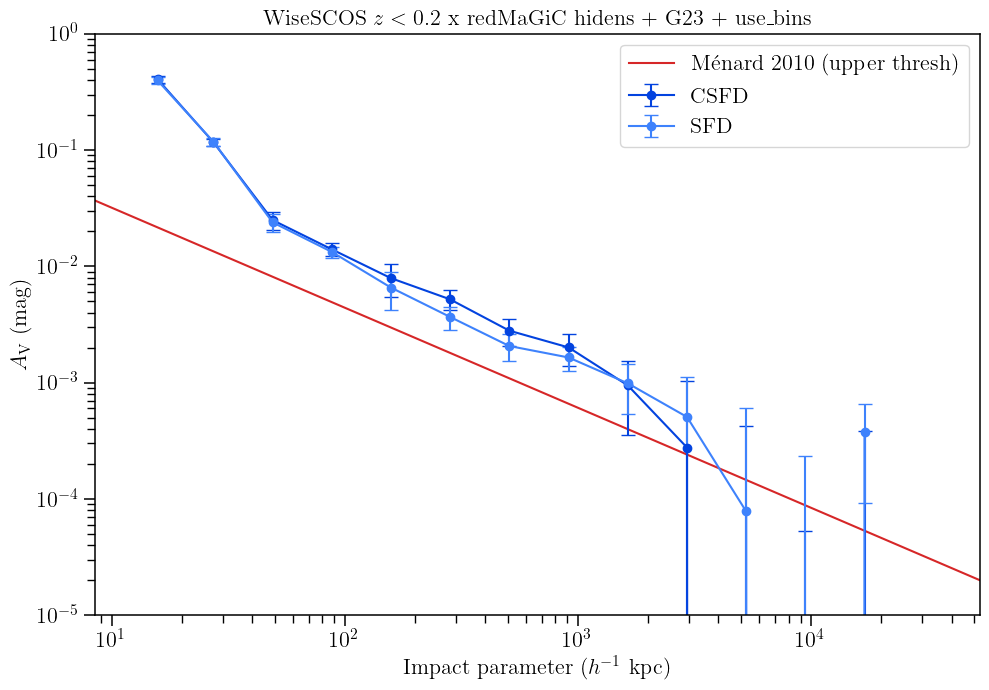

In [45]:
z_fg = 0.144 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (upper thresh)')

# What it says
ax.errorbar(dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD')

ax.errorbar(dk_hidens['meanr']*scl, dust_hidens_notcsfd,
            yerr=dk_hidens['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'SFD')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'WiseSCOS $z < 0.2$ x redMaGiC hidens + G23 + use\_bins', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_vs_not_hidens.png'
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}"
)
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}"
)


### Plot: high-lum high-z

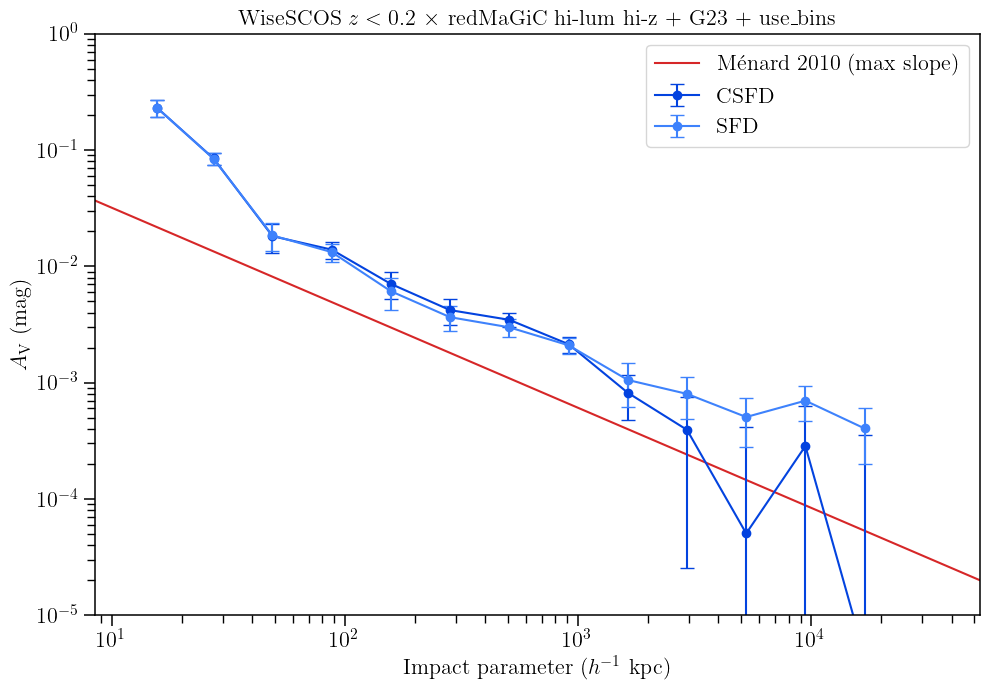

In [46]:
# Set z_theory and z_foreground levels
z_fg = 0.144 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010 (max slope)')

ax.errorbar(dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_csfd,
            yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD')

ax.errorbar(dk_hiz['meanr']*scl, dust_hiz_notcsfd,
            yerr=dk_hiz['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'SFD')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(
    r'WiseSCOS $z < 0.2 \ \times $ redMaGiC hi-lum hi-z + G23 + use\_bins', 
    fontsize=16
)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_vs_not_hidens.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Plot: redMaGiC LRG (`lowz_hidens_fg_x_hiz_bg`)

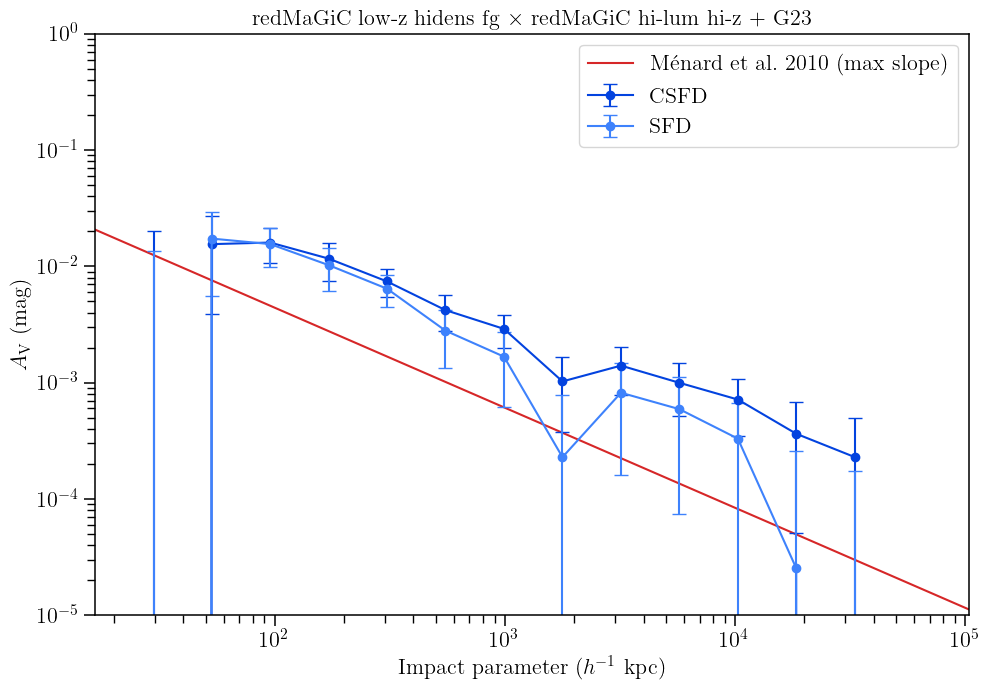

In [47]:
# Set z_theory and z_foreground levels
z_fg = 0.35 # lowz redmagic catalog
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard et al.~2010 (max slope)')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl, dust_lrg_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD')

ax.errorbar(dk_lrg['meanr']*scl, dust_lrg_notcsfd,
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'SFD')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'redMaGiC low-z hidens fg $\times$ redMaGiC hi-lum hi-z + G23', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_csfd_vs_not_lrg.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )


### Let's do a 1 x 3 for the report

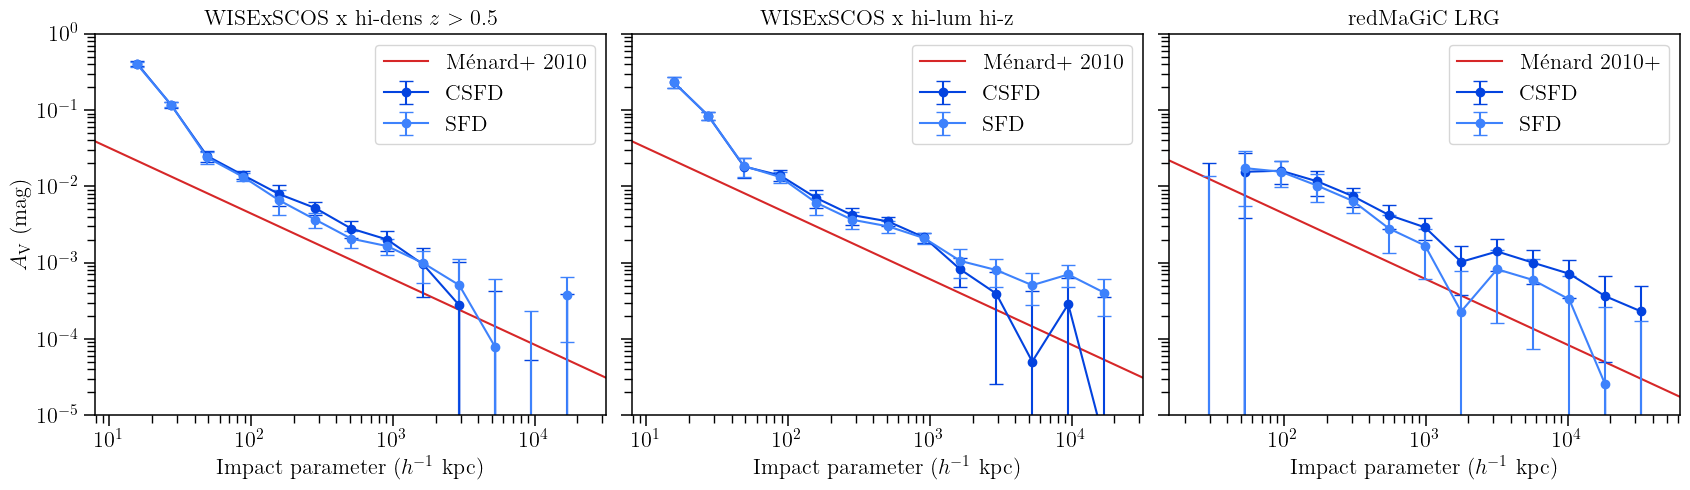

In [76]:
z_fg = 0.144 # lowz redmagic catalog
z_fg2 = 0.35 # lowz redmagic catalog

fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h


fig, axs = plt.subplots(1, 3, figsize=(17, 5), tight_layout=True, sharey=True)

###
### Start with hidens
axs[0].plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010')

axs[0].errorbar(dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD')

axs[0].errorbar(dk_hidens['meanr']*scl, dust_hidens_notcsfd,
            yerr=dk_hidens['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'SFD')

axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlim(0.075*scl, 300*scl)
axs[0].set_ylim(1E-5, 1)
axs[0].set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
axs[0].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[0].set_title('WISExSCOS x hi-dens $z>0.5$')
axs[0].legend(fontsize=16)

###
### Then high-lum high-z
axs[1].plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010')

axs[1].errorbar(dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_csfd,
            yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD')

axs[1].errorbar(dk_hiz['meanr']*scl, dust_hiz_notcsfd,
            yerr=dk_hiz['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'SFD')

axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlim(0.075*scl, 300*scl)
axs[1].set_ylim(1E-5, 1)
axs[1].set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
#axs[1].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[1].set_title('WISExSCOS x hi-lum hi-z')
axs[1].legend(fontsize=16)

###
### End on LRG
axs[2].plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard 2010+')

axs[2].errorbar(dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'CSFD')

axs[2].errorbar(dk_lrg['meanr']*scl2, dust_lrg_notcsfd,
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'SFD')

axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].set_xlim(0.075*scl2, 300*scl2)
axs[2].set_ylim(1E-5, 1)
#axs[2].set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
axs[2].set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
axs[2].set_title('redMaGiC LRG')
axs[2].legend(fontsize=16)

figname = 'dustcorrel_redmagic_csfd_vs_not_all.png'
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}"
)
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}"
)


## Plot: all CSFD samples

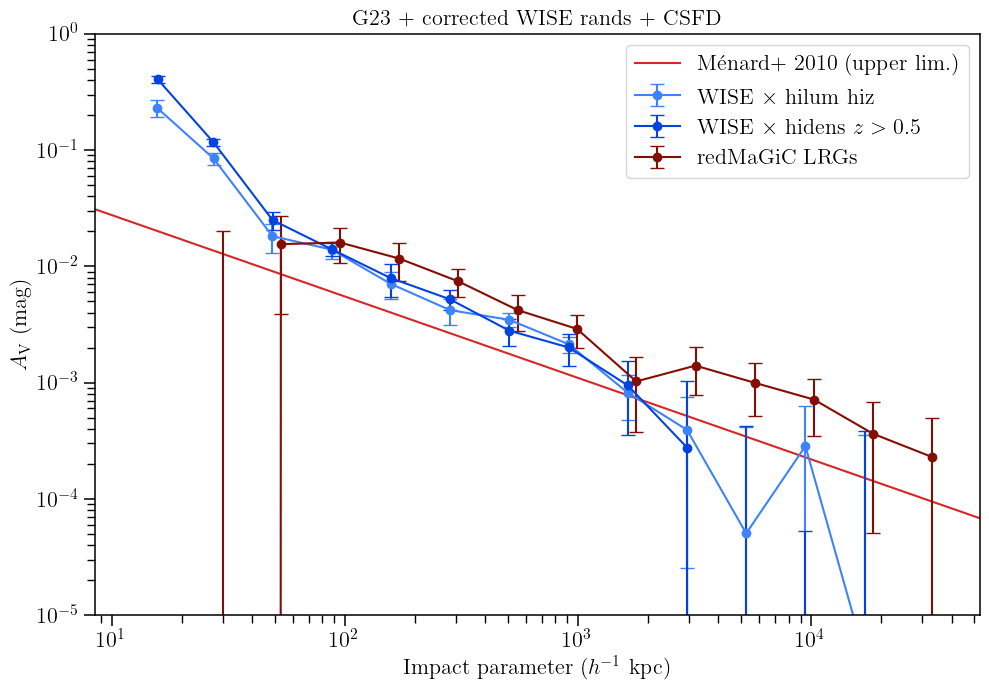

In [13]:
# Set z_theory and z_foreground levels
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(dk_hiz_newrand_csfd['meanr']*scl, dust_hiz_csfd,
            yerr=dk_hiz_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz')

ax.errorbar(dk_hidens_newrand_csfd['meanr']*scl, dust_hidens_csfd,
            yerr=dk_hidens_newrand_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$')

ax.errorbar(dk_lrg_usebins_csfd['meanr']*scl2, dust_lrg_csfd,
            yerr=dk_lrg_usebins_csfd['sigma'], fmt='-o', capsize=5, 
            color='xkcd:indian red', label=r'redMaGiC LRGs')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
#ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)
ax.set_title(r'G23 + corrected WISE rands + CSFD', fontsize=16)

figname = 'dustcorrel_redmagic_csfd_newrand_comp.png'
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}"
)
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}"
)


## Plot non-CSFD fits

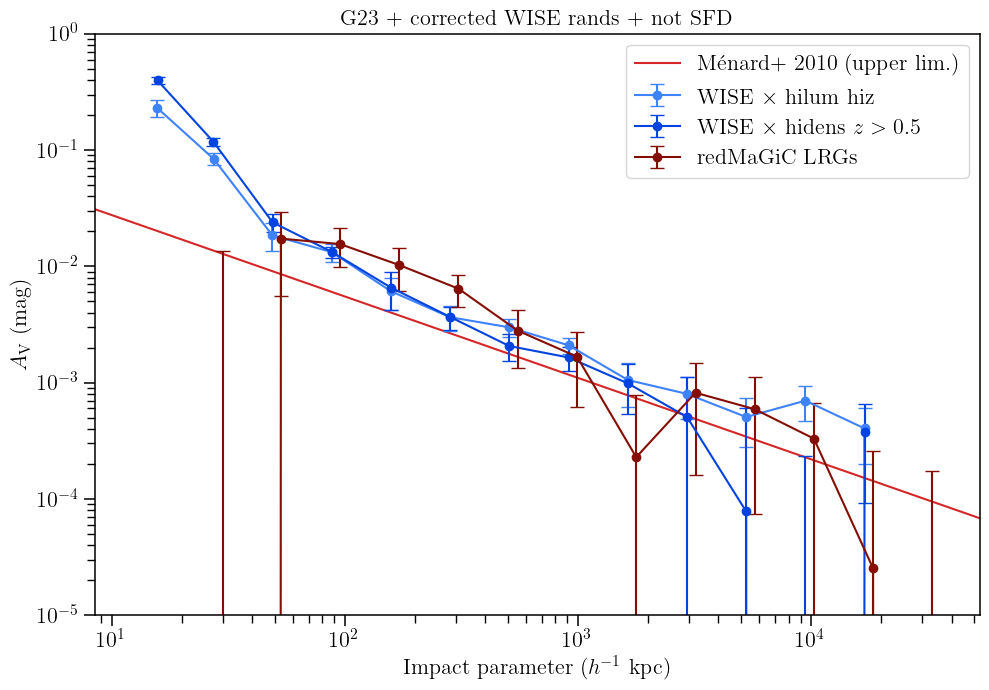

In [14]:
# Set z_theory and z_foreground levels
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(dk_hiz['meanr']*scl, dust_hiz_notcsfd,
            yerr=dk_hiz['sigma'], fmt='-o', capsize=5, 
            color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz')

ax.errorbar(dk_hidens['meanr']*scl, dust_hidens_notcsfd,
            yerr=dk_hidens['sigma'], fmt='-o', capsize=5, 
            color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$')

ax.errorbar(dk_lrg['meanr']*scl2, dust_lrg_notcsfd,
            yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
            color='xkcd:indian red', label=r'redMaGiC LRGs')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'G23 + corrected WISE rands + not SFD', fontsize=16)
ax.legend(fontsize=16)

figname = 'dustcorrel_redmagic_not_csfd_newrand_comp.png'
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}"
)
fig.savefig(
    f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}"
)


# Calculate fits for non-CSFD

## Hiz & hidens indiv fits

In [15]:
res_hiz = do_WLS_fit(
    dk_hiz, dust_hiz_notcsfd, 
    name='high-lum high-z', start=2, end=11, log=True
)
print(res_hiz.params)

print("")

print(f"Fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")


'''
res_hiz_inner = do_WLS_fit(
    dk_hiz_newrand_csfd, dust_hiz_newrand_csfd, 
    name='high-lum high-z inner', start=0, end=3, log=True
)
print(res_hiz_inner.params)
print(f"Fit: {np.exp(res_hiz_inner.params[0]):.2e} * (meanr)^{res_hiz_inner.params[1]:.2f}")
'''


Fit result: high-lum high-z

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.987
Model:                            WLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                     545.0
Date:                Wed, 23 Oct 2024   Prob (F-statistic):           6.72e-08
Time:                        19:25:14   Log-Likelihood:                 5.6611
No. Observations:                   9   AIC:                            -7.322
Df Residuals:                       7   BIC:                            -6.928
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.6556 

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


'\nres_hiz_inner = do_WLS_fit(\n    dk_hiz_newrand_csfd, dust_hiz_newrand_csfd, \n    name=\'high-lum high-z inner\', start=0, end=3, log=True\n)\nprint(res_hiz_inner.params)\nprint(f"Fit: {np.exp(res_hiz_inner.params[0]):.2e} * (meanr)^{res_hiz_inner.params[1]:.2f}")\n'

In [16]:
res_hidens = do_WLS_fit(
    dk_hidens, dust_hidens_notcsfd, 
    name='WISExSCOS x high-density', start=2, log=True
)
print(res_hidens.params)

print("")

print(f"Fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")



Fit result: WISExSCOS x high-density

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.769
Model:                            WLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     26.59
Date:                Wed, 23 Oct 2024   Prob (F-statistic):           0.000867
Time:                        19:25:14   Log-Likelihood:                -10.520
No. Observations:                  10   AIC:                             25.04
Df Residuals:                       8   BIC:                             25.65
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


## Combined redMaGiC WLS fit

In [17]:
###
### Combined fit!
###

stacked_dk = vstack([dk_hiz, dk_hidens])
stacked_dust = np.concatenate([dust_hiz_notcsfd, dust_hidens_notcsfd])
stacked_dk.add_column(stacked_dust, name='dust_column')
stacked_dk.sort('meanlogr')
stacked_dust_col = np.array(stacked_dk['dust_column'])
print(stacked_dk)

 r_nom   meanr  meanlogr    kappa      sigma       weight       npairs          dust_column      
------- ------- -------- ----------- ---------- ------------ ------------ -----------------------
0.13396 0.14732  -1.9269     0.22878   0.038481       913.01       3477.0     0.23102999999999996
0.13396 0.14811  -1.9213     0.40076    0.02627       743.62       3727.0     0.39708999999999994
0.24037 0.25734  -1.3702     0.11528  0.0087879       3163.8      15857.0      0.1176600000000001
0.24037 0.25754  -1.3692    0.083461  0.0097633       4056.4      15434.0                0.084121
0.43133 0.46098 -0.78717    0.017366  0.0050232      12430.0      47308.0    0.018435999999999897
0.43133 0.46145 -0.78612    0.023456  0.0043178      10154.0      50890.0     0.02389600000000003
  0.774 0.82706 -0.20244    0.012376  0.0023501      38744.0     147440.0    0.013256000000000046
  0.774 0.82758 -0.20167    0.013377  0.0014648      31602.0     158390.0    0.013317000000000023
 1.3889  1.4838  0.3

In [18]:
res_stacked = do_WLS_fit(
    stacked_dk, stacked_dust_col, 
    name='stacked redMaGiC', start=4, end=16, log=True
)
print(res_stacked.params)
print(f"Fit: {np.exp(res_stacked.params[0]):.2e} * (meanr)^{res_stacked.params[1]:.2f}")


Fit result: stacked redMaGiC

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.894
Model:                            WLS   Adj. R-squared:                  0.884
Method:                 Least Squares   F-statistic:                     84.60
Date:                Wed, 23 Oct 2024   Prob (F-statistic):           3.40e-06
Time:                        19:25:16   Log-Likelihood:               -0.67157
No. Observations:                  12   AIC:                             5.343
Df Residuals:                      10   BIC:                             6.313
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.7420

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=12
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


In [19]:
res_lrg = do_WLS_fit(
    dk_lrg, dust_lrg_notcsfd, 
    name='redmagic LRG', start=3, end=12, log=True
)
print(res_lrg.params)

print("")

print(f"Fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")


Fit result: redmagic LRG

                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.664
Model:                            WLS   Adj. R-squared:                  0.616
Method:                 Least Squares   F-statistic:                     13.85
Date:                Wed, 23 Oct 2024   Prob (F-statistic):            0.00744
Time:                        19:25:17   Log-Likelihood:                -14.648
No. Observations:                   9   AIC:                             33.30
Df Residuals:                       7   BIC:                             33.69
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.4174    

/Users/j.mccleary/Software/miniconda3/envs/jupyterlab/lib/python3.11/site-packages/scipy/stats/_stats_py.py:1736: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=9
  warnings.warn("kurtosistest only valid for n>=20 ... continuing "


### Print WLS outputs

In [20]:
###
### Print fit results
### 
print(f"Hi-dens WLS fit: {np.exp(res_hidens.params[0]):.2e} * (meanr)^{res_hidens.params[1]:.2f}")
print(f"Hi-z WLS fit: {np.exp(res_hiz.params[0]):.2e} * (meanr)^{res_hiz.params[1]:.2f}")
print(f"Combined WLS fit: {np.exp(res_stacked.params[0]):.2e} * (meanr)^{res_stacked.params[1]:.2f}")
print(f"LRG WLS fit: {np.exp(res_lrg.params[0]):.2e} * (meanr)^{res_lrg.params[1]:.2f}")
print("")

print("WISExSCOS x redMaGiC high-dens WLS:")
print(f"  Const: {res_hidens.params[0]:.3e} +/- {res_hidens.bse[0]:.3e}")
print(f"  Slope: {res_hidens.params[1]:.3e} +/- {res_hidens.bse[1]:.3e}")

print("")

print("WISExSCOS x redMaGiC high-lum high-z WLS:")
print(f"  Const: {res_hiz.params[0]:.3e} +/- {res_hiz.bse[0]:.3e}")
print(f"  Slope: {res_hiz.params[1]:.3e} +/- {res_hiz.bse[1]:.3e}")

print("")

print("Combined WISExSCOS x redMaGiC WLS:")
print(f"  Const: {res_stacked.params[0]:.3e} +/- {res_stacked.bse[0]:.3e}")
print(f"  Slope: {res_stacked.params[1]:.3e} +/- {res_stacked.bse[1]:.3e}")

print("")

print("low-z redMaGiC hi-dens x redMaGiC hi-lum hi-z WLS:")
print(f"  Const: {res_lrg.params[0]:.3e} +/- {res_lrg.bse[0]:.3e}")
print(f"  Slope: {res_lrg.params[1]:.3e} +/- {res_lrg.bse[1]:.3e}")


Hi-dens WLS fit: 5.86e-03 * (meanr)^-0.62
Hi-z WLS fit: 9.51e-03 * (meanr)^-0.75
Combined WLS fit: 8.72e-03 * (meanr)^-0.74
LRG WLS fit: 1.21e-02 * (meanr)^-1.18

WISExSCOS x redMaGiC high-dens WLS:
  Const: -5.140e+00 +/- 3.981e-01
  Slope: -6.177e-01 +/- 1.198e-01

WISExSCOS x redMaGiC high-lum high-z WLS:
  Const: -4.656e+00 +/- 9.686e-02
  Slope: -7.525e-01 +/- 3.224e-02

Combined WISExSCOS x redMaGiC WLS:
  Const: -4.742e+00 +/- 1.444e-01
  Slope: -7.392e-01 +/- 8.036e-02

low-z redMaGiC hi-dens x redMaGiC hi-lum hi-z WLS:
  Const: -4.417e+00 +/- 1.155e+00
  Slope: -1.183e+00 +/- 3.178e-01


## Also try unweighted linear regression

In [31]:
linregress_hidens = stats.linregress(
    dk_hidens['meanlogr'][2:10], 
    np.log(dust_hidens_notcsfd[2:10])
)
linregress_hiz = stats.linregress(
    dk_hiz['meanlogr'][2:10], 
    np.log(dust_hiz_notcsfd[2:10])
)
linregress_stacked = stats.linregress(
    stacked_dk['meanlogr'][4:16], 
    np.log(stacked_dust_col[4:16])
)
linregress_lrg = stats.linregress(
    dk_lrg['meanlogr'][2:11], 
    np.log(dust_lrg_notcsfd[2:11])
)

print("high-dens params")
print(linregress_hidens)
print("")

print("high-z params")
print(linregress_hiz)
print("")

print("combined params")
print(linregress_stacked)
print("")

print("LRG params")
print(linregress_lrg)
print("")

print(f"High-dens LSQ fit: {np.exp(linregress_hidens[1]):.2e} * (meanr)^{linregress_hidens[0]:.2f}")
print(f"High-z LSQ fit: {np.exp(linregress_hiz[1]):.2e} * (meanr)^{linregress_hiz[0]:.2f}")
print(f"Combined LSQ fit: {np.exp(linregress_stacked[1]):.2e} * (meanr)^{linregress_stacked[0]:.2f}")
print(f"LRG LSQ fit: {np.exp(linregress_lrg[1]):.2e} * (meanr)^{linregress_lrg[0]:.2f}")

print("")

print("WISExSCOS x hi-density LSQ:")
print(f"  Const: {linregress_hidens.intercept:.3e} +/- {linregress_hidens.intercept_stderr:.3e}")
print(f"  Slope: {linregress_hidens.slope:.3e} +/- {linregress_hidens.stderr:.3e}")
print("")
print("WISExSCOS x hi-density LSQ:")
print(f"  Const: {linregress_hiz.intercept:.3e} +/- {linregress_hiz.intercept_stderr:.3e}")
print(f"  Slope: {linregress_hiz.slope:.3e} +/- {linregress_hiz.stderr:.3e}")
print("")
print("Combined WISExSCOS x redMaGiC LSQ:")
print(f"  Const: {linregress_stacked.intercept:.3e} +/- {linregress_stacked.intercept_stderr:.3e}")
print(f"  Slope: {linregress_stacked.slope:.3e} +/- {linregress_stacked.stderr:.3e}")
print("")
print("redMaGiC LRG LSQ:")
print(f"  Const: {linregress_lrg.intercept:.3e} +/- {linregress_lrg.intercept_stderr:.3e}")
print(f"  Slope: {linregress_lrg.slope:.3e} +/- {linregress_lrg.stderr:.3e}")


high-dens params
LinregressResult(slope=-0.9098806153676049, intercept=-4.575885612292966, rvalue=-0.9949226763064367, pvalue=3.2597875947731155e-07, stderr=0.03757508030437055, intercept_stderr=0.06915968328623386)

high-z params
LinregressResult(slope=-0.7736960479719152, intercept=-4.648766948260717, rvalue=-0.9922217705328126, pvalue=1.1696213207422571e-06, stderr=0.03962736708693534, intercept_stderr=0.07293879580653055)

combined params
LinregressResult(slope=-0.8644685321914097, intercept=-4.606250346753914, rvalue=-0.9829934343425275, pvalue=1.0888896622570977e-08, stderr=0.0510701954689844, intercept_stderr=0.06161143584833944)

LRG params
LinregressResult(slope=-0.8712224824775036, intercept=-4.981081503321304, rvalue=-0.9186061424351658, pvalue=0.00046744481780105, stderr=0.1416574566939062, intercept_stderr=0.3069515895295389)

High-dens LSQ fit: 1.03e-02 * (meanr)^-0.91
High-z LSQ fit: 9.57e-03 * (meanr)^-0.77
Combined LSQ fit: 9.99e-03 * (meanr)^-0.86
LRG LSQ fit: 6.87e-0

## Last step: plots with fits :-) 

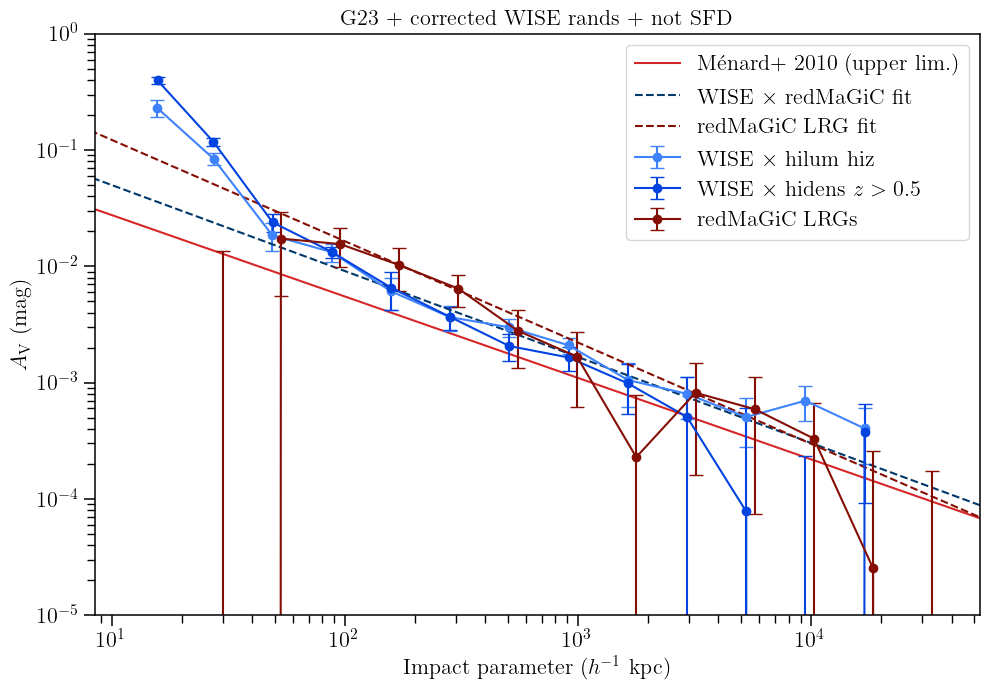

In [37]:
# Set z_theory and z_foreground levels
z_fg = 0.144
z_fg2 = 0.35 # Filtered WISExSCOS
fg_gal_kpc = cosmo.kpc_proper_per_arcmin(z_fg)
fg_gal_kpc2 = cosmo.kpc_proper_per_arcmin(z_fg2)

# Converts us from arcminutes to h^-1 kpc 
# Menard relationship was in terms of h
scl = fg_gal_kpc.value * cosmo.h
scl2 = fg_gal_kpc2.value * cosmo.h

##
## Also plot fits
##
a = res_stacked.params[1]; A = np.exp(a) # Power
b = res_stacked.params[0]; B = np.exp(b) # Coefficient
#a = linregress_stacked[0]
#b = linregress_stacked[1]

fit_redmagic = B * (theory_r_arcmin**a)

#a = res_lrg.params[1]; A = np.exp(a) # Power
#b = res_lrg.params[0]; B = np.exp(b) # Coefficient
a = linregress_lrg[0]
b = linregress_lrg[1]
fit_lrg = B * (theory_r_arcmin**a)

#print(f"  Const: {res_lrg.params[0]:.3e} +/- {res_lrg.bse[0]:.3e}")
#print(f"  Slope: {res_lrg.params[1]:.3e} +/- {res_lrg.bse[1]:.3e}")


fig, ax = plt.subplots(figsize=(10, 7), tight_layout=True)

ax.plot(theory_r, av, color='tab:red',
        label=r'M\'{e}nard+ 2010 (upper lim.)')
# What it says

ax.errorbar(
    dk_hiz['meanr']*scl, dust_hiz_notcsfd,
    yerr=dk_hiz['sigma'], fmt='-o', capsize=5, 
    color='xkcd:dodger blue', label=r'WISE $\times$ hilum hiz'
)

ax.errorbar(
    dk_hidens['meanr']*scl, dust_hidens_notcsfd,
    yerr=dk_hidens['sigma'], fmt='-o', capsize=5, 
    color='xkcd:blue', label=r'WISE $\times$ hidens $z>0.5$'
)

ax.plot(
    theory_r_arcmin*scl, fit_redmagic, 
    linestyle='--', color='xkcd:marine blue', 
    label=r'WISE $\times$ redMaGiC fit'
)

ax.errorbar(
    dk_lrg['meanr']*scl2, dust_lrg_notcsfd,
    yerr=dk_lrg['sigma'], fmt='-o', capsize=5, 
    color='xkcd:indian red', label=r'redMaGiC LRGs'
)

ax.plot(
    theory_r_arcmin*scl2, fit_lrg, 
    linestyle='--', color='xkcd:indian red', 
    label=r'redMaGiC LRG fit'
)


ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.08*scl, 500*scl)
ax.set_ylim(1E-5, 1)
ax.set_xlabel(r'Impact parameter ($h^{-1}$ kpc)', fontsize=16)
ax.set_ylabel(r'$A_{\rm V}$ (mag)', fontsize=16)
ax.set_title(r'', fontsize=16)
ax.legend(fontsize=16)
ax.set_title(r'G23 + corrected WISE rands + not SFD', fontsize=16)

figname = 'dustcorrel_redmagic_notcsfd_withfits_wls.png'
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/output/{figname}" )
fig.savefig(f"/Users/j.mccleary/Research/dusty_halos/dusthalos_emh/writeup/figures_update2/{figname}" )
